# **1. Carga de datos**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Copie la ruta del archivo CSV en la celda a continuación para cargar los datos:

data = pd.read_csv('//Users/davasgo2702/mlops-pipeline-proyecto-CD/BD_creditos.csv', sep=';')
data.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,4,7/01/2025 14:40,1852560,12,32,Empleado,3500000,1000000,128650,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,916148.0,Creciente,1
1,4,9/01/2025 11:18,3181080,6,34,Empleado,5000000,2000000,441817,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,4473774.0,Creciente,1
2,9,26/12/2024 18:52,670200,5,34,Independiente,5000000,2000000,108632,"95,227787",...,0.0,274561.0,274561.0,NaN,2,0,1,NaN,NaN,1
3,9,4/12/2024 14:20,506807,2,25,Independiente,3000000,900000,199684,"95,227787",...,0.0,27564.0,27564.0,NaN,1,0,6,NaN,NaN,1
4,4,30/04/2025 18:41,999780,10,26,Empleado,2000000,600000,92509,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,61000.0,Creciente,1


# **2. Exploracion inicial de datos**

**DESCRIPCION GENERAL DE LOS DATOS**

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  category      
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  int64         
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  category      
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

El dataset contiene 10,763 créditos con 23 atributos. Se identifican variables tipo "object" que deben tipificarse correctamente: `tipo_laboral` y `tendencia_ingresos` se convierten a "category" por ser variables categóricas (nominal y ordinal respectivamente), y `fecha_prestamo` se convierte a "datetime64". La variable `puntaje`, aunque llega como texto por usar coma como separador decimal, corresponde en realidad a una variable numérica continua, por lo que se convierte a "float64" (reemplazando la coma por punto) y no a "category". Adicionalmente, `tipo_credito`, aunque se almacena como "int64", codifica categorías nominales de producto de crédito, por lo que también se convierte a "category". Con respecto a `Pago_atiempo` (posible target), se convierte a "category" para el análisis exploratorio, ya que aunque maneja valores enteros (1,0), estos representan en realidad una variable dicotómica (Sí/No).

Se identifican 7 variables con datos faltantes. Se observa que los nulos de `promedio_ingresos_datacredito` y `tendencia_ingresos` coinciden casi exactamente en volumen, sugiriendo un origen común (probable falla en una consulta externa a centrales de riesgo).

Las variables se agrupan en tres grandes familias:
1. Variables del crédito (tipo, capital, plazo, cuota).
2. Variables del cliente (edad, salario, tipo laboral).
3. Variables de comportamiento crediticio externo (score, saldos, historial en centrales de riesgo).



**Unificacion de valores nulos**

In [6]:
# Unificar la forma en que se representan los nulos:
# Mostrar el recuento de valores nulos por columna
null_counts = data.isnull().sum()

# Filtrar y mostrar solo las columnas que tienen valores nulos
null_columns = null_counts[null_counts > 0]

if not null_columns.empty:
    print("Columnas con valores nulos y su recuento:")
    print(null_columns)
    print("\nTodos los valores nulos están representados como NaN estándar.")
else:
    print("No hay valores nulos en el DataFrame.")

Columnas con valores nulos y su recuento:
puntaje_datacredito                 6
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
dtype: int64

Todos los valores nulos están representados como NaN estándar.


**Correcion de tipificacion de variables**

In [7]:
data["tipo_laboral"]=data["tipo_laboral"].astype("category")
data["tendencia_ingresos"]=data["tendencia_ingresos"].astype("category")
data["Pago_atiempo"]=data["Pago_atiempo"].astype("category")
data["tipo_credito"]=data["tipo_credito"].astype("category")

# Reemplazar la coma por un punto antes de convertir a float
data['puntaje'] = data['puntaje'].str.replace(',', '.').astype('float64')
data['fecha_prestamo'] = pd.to_datetime(data['fecha_prestamo'], format='%d/%m/%Y %H:%M')
data.info()

AttributeError: Can only use .str accessor with string values!

**ELIMINACION DE VARIABLES IRRELEVANTES**

Se revisó cada variable buscando columnas constantes (varianza cero) o de tipo identificador
(valores únicos por registro), sin encontrar ninguna. Todas las 23 variables presentan
variabilidad y potencial informativo, por lo que no se elimina ninguna en esta etapa.

# **3. Exploracion de datos y descripcion (EDA)**

**ANALISIS UNIVARIABLE**

In [8]:
data.describe()

,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito
count,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10757.000000,10763.000000,10763.000000,10607.000000,1.060700e+04,1.035800e+04,10173.000000,10763.000000,10763.000000,10763.000000,7.833000e+03
mean,2025-04-16 23:05:32.851435520,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,780.790834,5.726749,4.228561,7.746017,4.593741e+04,4.034617e+04,0.260002,2.779987,0.269813,1.302704,2.005157e+06
min,2024-11-26 09:17:00,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,-7.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2025-01-20 17:32:30,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,3.000000,2.000000,0.000000,2.898000e+03,2.690000e+03,0.000000,1.000000,0.000000,0.000000,9.251570e+05
50%,2025-03-27 16:23:00,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,5.000000,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06
75%,2025-06-16 13:27:30,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,8.000000,6.000000,0.000000,5.298200e+04,4.763225e+04,0.000000,4.000000,0.000000,2.000000,2.231859e+06
max,2026-04-26 18:43:00,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,62.000000,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07
std,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,104.878031,3.977162,3.064683,225.955117,1.062698e+05,7.124244e+04,21.772917,2.748807,0.716471,1.824430,2.144116e+06


**Se hace un data Profiling para tener toda la analitica encapsulada en un .html**

In [9]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=True) # minimal=True
profile_data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.9 MB/s eta 0:00:00


/tmp/ipykernel_554/340952533.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 23/23 [00:00<00:00, 57.59it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

**Análisis variable por variable**

**Variables del credito**

* `tipo_credito`: Variable Categórica nominal, muy concentrada en código 4 (72%) y 9 (27%) explican el 99% de los casos. El 68 (1 solo registro, 0.01%) rompe el patrón no es de producto real, es error de digitación.
* `fecha_prestamo`: Variable temporal, Cubre desembolsos entre el 26-nov-2024 y el 26-abr-2026 (17 meses). Su relevancia va más allá de ser cronológica: hay un posible sesgo de maduración (vintage) — los créditos más recientes no han tenido tiempo de caer en mora, y ya confirmamos que la tasa de "pago a tiempo" sube de ~93% en los primeros meses a ~98% en los últimos.
* `capital_prestado`: Variable numerica continua, Media 2.43M, mediana 1.92M — asimetría positiva fuerte (skew 3.72), típica de montos de crédito. Sin ceros ni negativos, rango internamente consistente.
* `plazo_meses`: Variable numerica discreta con 18 valores entre 2 y 90 meses, moda en 6. Asimetría moderada (skew 2.46).
* `cuota_pactada`: Variable numerica continua con comportamiento espejo de capital_prestado (esperable, están matemáticamente ligadas: cuota ≈ f(capital, plazo, tasa)).

**Variables del cliente**

* `edad_cliente`: Variable numerica discreta, Media 43.9 años, mediana 42 — distribución razonable para un portafolio de crédito de consumo. El máximo reportado (123) es un artefacto: 150 registros (1.4%) tienen exactamente 121, 122 o 123 años, un valor centinela de dato faltante disfrazado de edad real.
* `tipo_laboral`: Variable categorica nominal dicotomica, Empleado 62.75% / Independiente 37.25% — balanceada, sin alertas.
* `salario_cliente`: Variable numerica continua, Aquí hay algo grave: skewness=43.8, kurtosis=2210 (para referencia, una normal tiene kurtosis≈0). 74 registros superan los COP 100 millones mensuales, con un máximo de COP 22.000 millones. Esto no es asimetría natural de ingresos — es un patrón de error de captura (probable exceso de ceros/error de escala en la digitación). También hay 24 registros en 0.
* `total_otros_prestamos`: Variable numerica continua, Mismo patrón que salario_cliente: 44 registros > $100M, máximo $6.787 millones. Mismo tipo de problema de escala.

**Comportamiento crediticio externo**

* `puntaje`: Variable numerica continua, 87% concentrado en un único valor (95.227787), 135 registros negativos (mínimo -38). Sospecha fuerte de data leakage.
* `puntaje_datacredito`: Variable numerica continua, Rango real 7–999 excluyendo el artefacto. 145 ceros + 1 valor negativo (-7) — inconsistentes con un score real de central de riesgo.
* `cant_creditosvigentes, huella_consulta, creditos_sectorFinanciero/Cooperativo/Real`: Variables numericas discretas, Todas con asimetría positiva moderada-alta y proporción relevante de ceros — comportamiento esperado en variables de conteo, sin anomalías estructurales.
* `saldo_mora, saldo_total, saldo_principal, saldo_mora_codeudor`: Variables numericas continuas, Fuertemente concentradas en cero (98%, 7.3%, 5.9%, 94.5% respectivamente) — coherente con que la mayoría de créditos no están en mora. Asimetrías extremas por eso mismo.
* `promedio_ingresos_datacredito`: Variable numerica continua, 	27.2% nulos (vinculados al fallo de fuente externa ya identificado) + 7 ceros adicionales sospechosos del mismo patrón.
* `tendencia_ingresos`: Variable categorica ordinal,Creciente 49.2%, Decreciente 12.0%, Estable 11.0%. El 27.2% son nulos, coincidiendo casi exactamente con los nulos de promedio_ingresos_datacredito (mismo origen: fallo de fuente externa).

**Target**

* `Pago_atiempo`: Variable categorica dicotomica, 95.25% de los créditos se paga a tiempo (1) vs 4.75% en mora (0). Desbalance fuerte de clases — condiciona la métrica de evaluación de cualquier modelo futuro (no usar accuracy simple; considerar recall/F1/AUC o técnicas de balanceo).



**ANALISIS BIVARIABLE**

In [10]:
# Correlacion point-biserial (numericas) -- documentar como hallazgo, no como criterio de eliminacion
data_temp_corr = data.select_dtypes(include=np.number).copy()
data_temp_corr['Pago_atiempo'] = data['Pago_atiempo'].astype(int)
corr_target = data_temp_corr.corr()['Pago_atiempo'].drop('Pago_atiempo').sort_values(key=abs, ascending=False)

# Asociacion categorica -- Cramer's V (para no dejar variables fuera)
from scipy.stats import chi2_contingency
def cramers_v(col, target):
    tabla = pd.crosstab(data[col], data[target])
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape)-1)))

for col in ['tipo_credito','tipo_laboral','tendencia_ingresos']:
    print(col, "Cramér's V:", round(cramers_v(col, 'Pago_atiempo'), 4))

tipo_credito Cramér's V: 0.08
tipo_laboral Cramér's V: 0.0273
tendencia_ingresos Cramér's V: 0.0462


Los resultados evidencian una asociación baja entre las variables categóricas y el cumplimiento del pago. `tipo_credito` presenta la mayor asociación con `Pago_atiempo` (Cramér’s V = 0.0800), seguido de `tendencia_ingresos` (0.0462) y `tipo_laboral` (0.0273). Aunque estas asociaciones son débiles, no implican que las variables deban eliminarse, ya que Cramér’s V mide asociación global y no permite descartar posibles relaciones específicas entre categorías. Por ello, se conservan para continuar con el análisis exploratorio y evaluar posteriormente su aporte dentro de un modelo predictivo.

In [11]:
# Calcular la correlación de todas las variables numéricas con 'Pago_atiempo'
# Primero, aseguramos que 'Pago_atiempo' sea numérico para la correlación.
# Como fue convertido a 'category' anteriormente, lo convertimos temporalmente a entero.
data_temp_corr = data.select_dtypes(include=np.number).copy()
data_temp_corr['Pago_atiempo'] = data['Pago_atiempo'].astype(int)

Pago_atiempo_correlations = data_temp_corr.corr()['Pago_atiempo'].sort_values(key=abs, ascending=False)

# Eliminar la autocorrelación de Pago_atiempo consigo mismo
Pago_atiempo_correlations = Pago_atiempo_correlations.drop('Pago_atiempo')

print("Correlaciones con 'Pago_atiempo' (ordenadas por valor absoluto):")
print(Pago_atiempo_correlations)

Correlaciones con 'Pago_atiempo' (ordenadas por valor absoluto):
puntaje                          0.923134
huella_consulta                 -0.073737
saldo_mora                      -0.073458
puntaje_datacredito              0.067882
plazo_meses                     -0.063105
capital_prestado                -0.040624
promedio_ingresos_datacredito    0.039867
edad_cliente                     0.032252
creditos_sectorReal             -0.023306
creditos_sectorFinanciero        0.021390
creditos_sectorCooperativo       0.021267
saldo_total                      0.014364
cuota_pactada                   -0.011814
saldo_principal                  0.011473
total_otros_prestamos           -0.010041
cant_creditosvigentes            0.008829
salario_cliente                 -0.003981
saldo_mora_codeudor              0.002631
Name: Pago_atiempo, dtype: float64




La variable `puntaje` muestra una correlación de 0.92. Este valor es extremadamente alto y sugiere un posible Data Leakage (fuga de información). Es probable que este puntaje se calcule después de conocer el estado de pago o que lo incluya directamente, por lo que debe revisarse con el negocio antes de incluirlo en un modelo real.

Varias variables numéricas muestran una correlación lineal baja (|r| < 0.015) con el target
en su estado actual: `saldo_total`, `cuota_pactada`, `saldo_principal`, `cant_creditosvigentes`,
`salario_cliente`, `total_otros_prestamos`. Sin embargo, esta lectura debe tomarse con cautela:


1. El coeficiente de Pearson solo detecta relaciones lineales y el target está fuertemente
desbalanceado, lo que comprime todas las correlaciones hacia cero.

2. Algunas de estas
variables aún contienen outliers/artefactos sin limpiar que distorsionan el coeficiente. La decisión de eliminarlas o transformarlas se aplazará a la etapa de
feature engineering, una vez los datos estén limpios y se puedan evaluar con criterios
adicionales (importancia en modelo, relevancia de negocio).

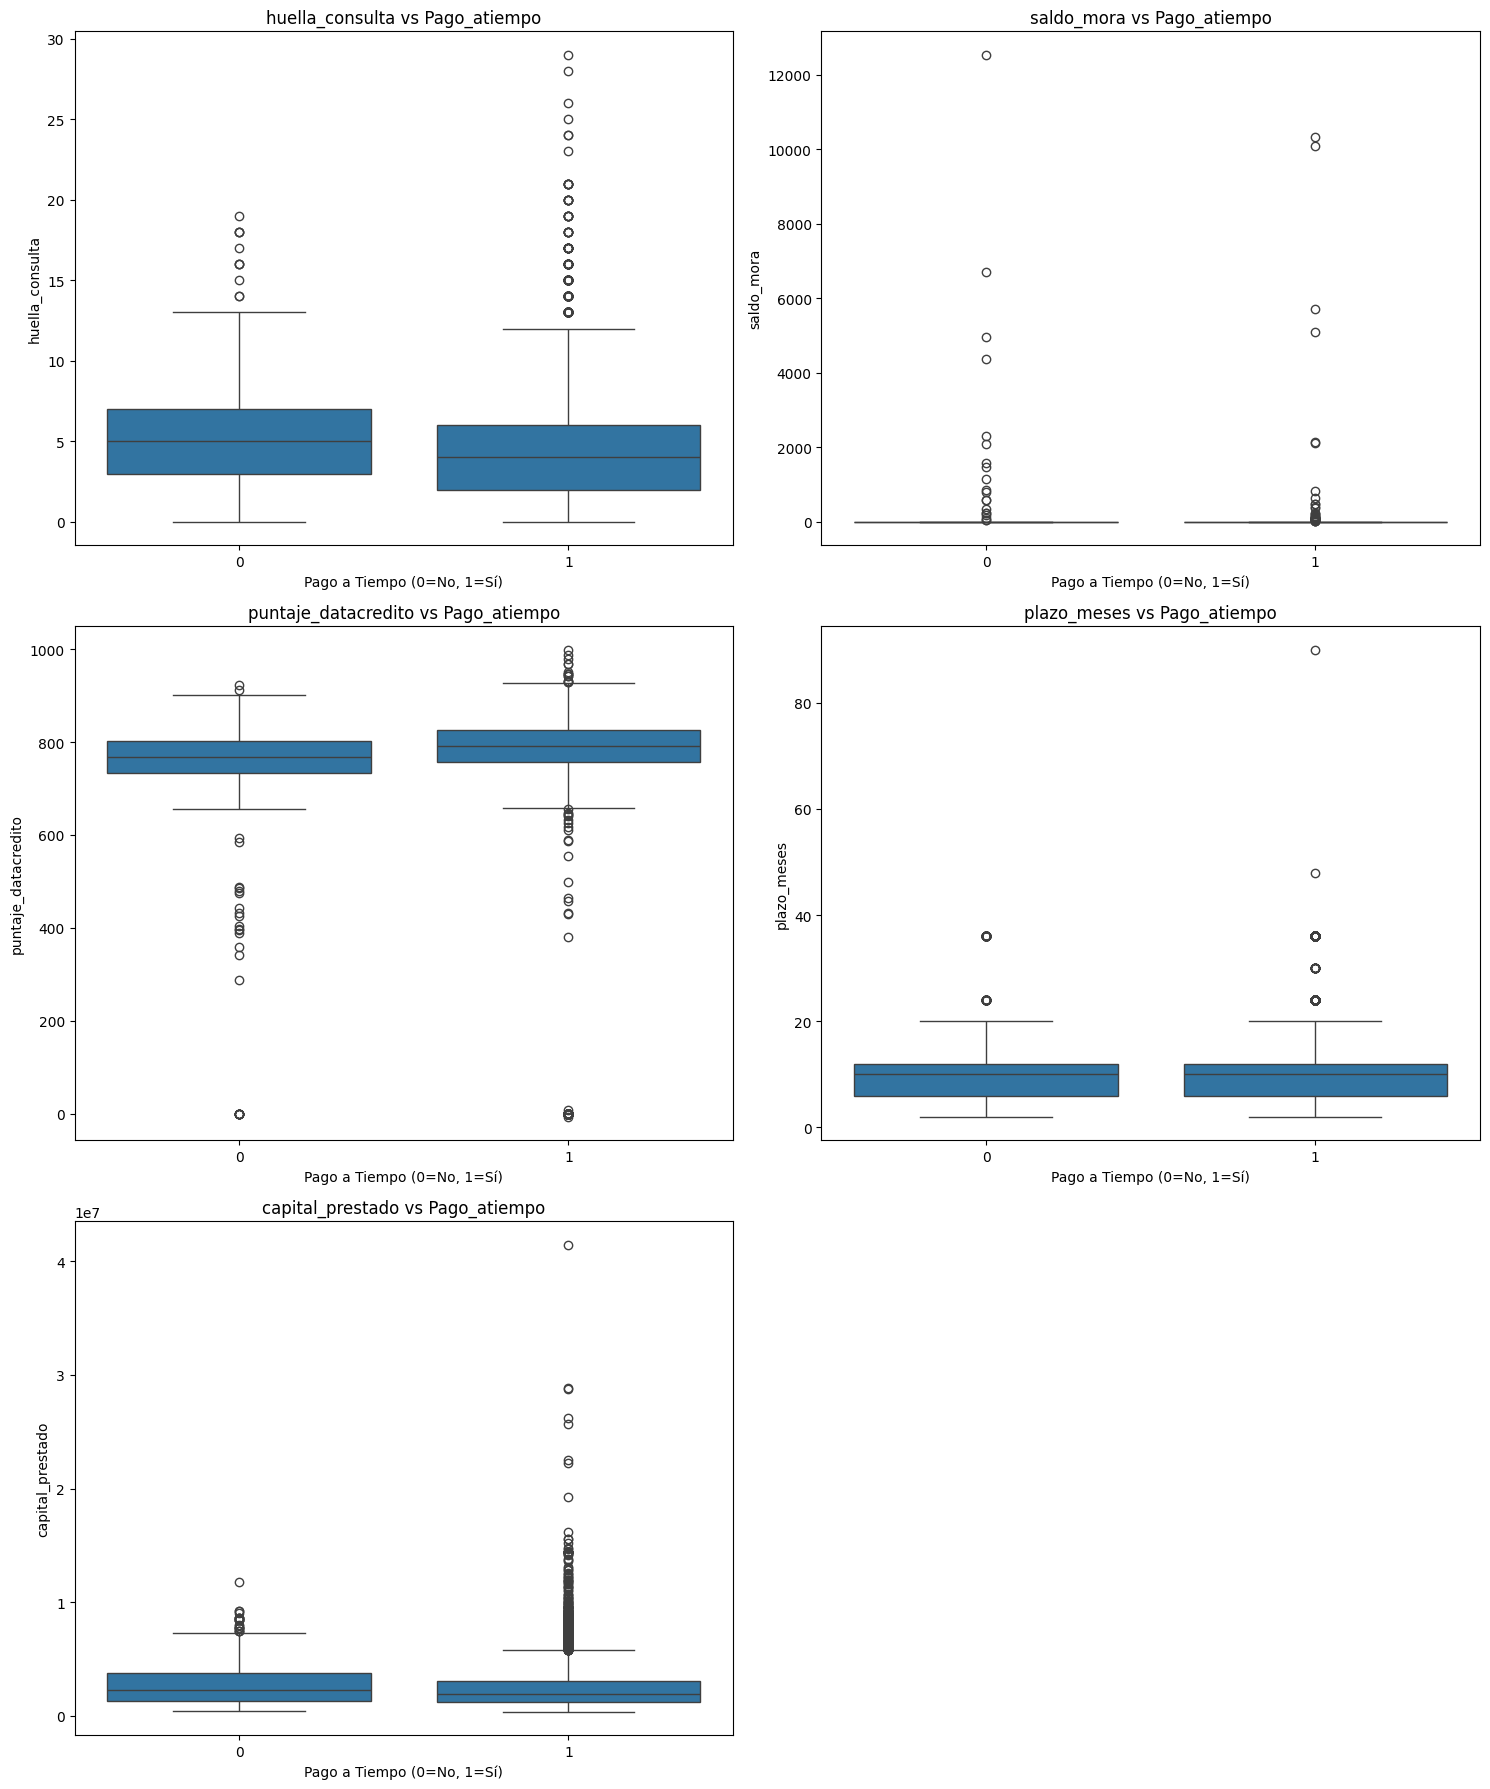

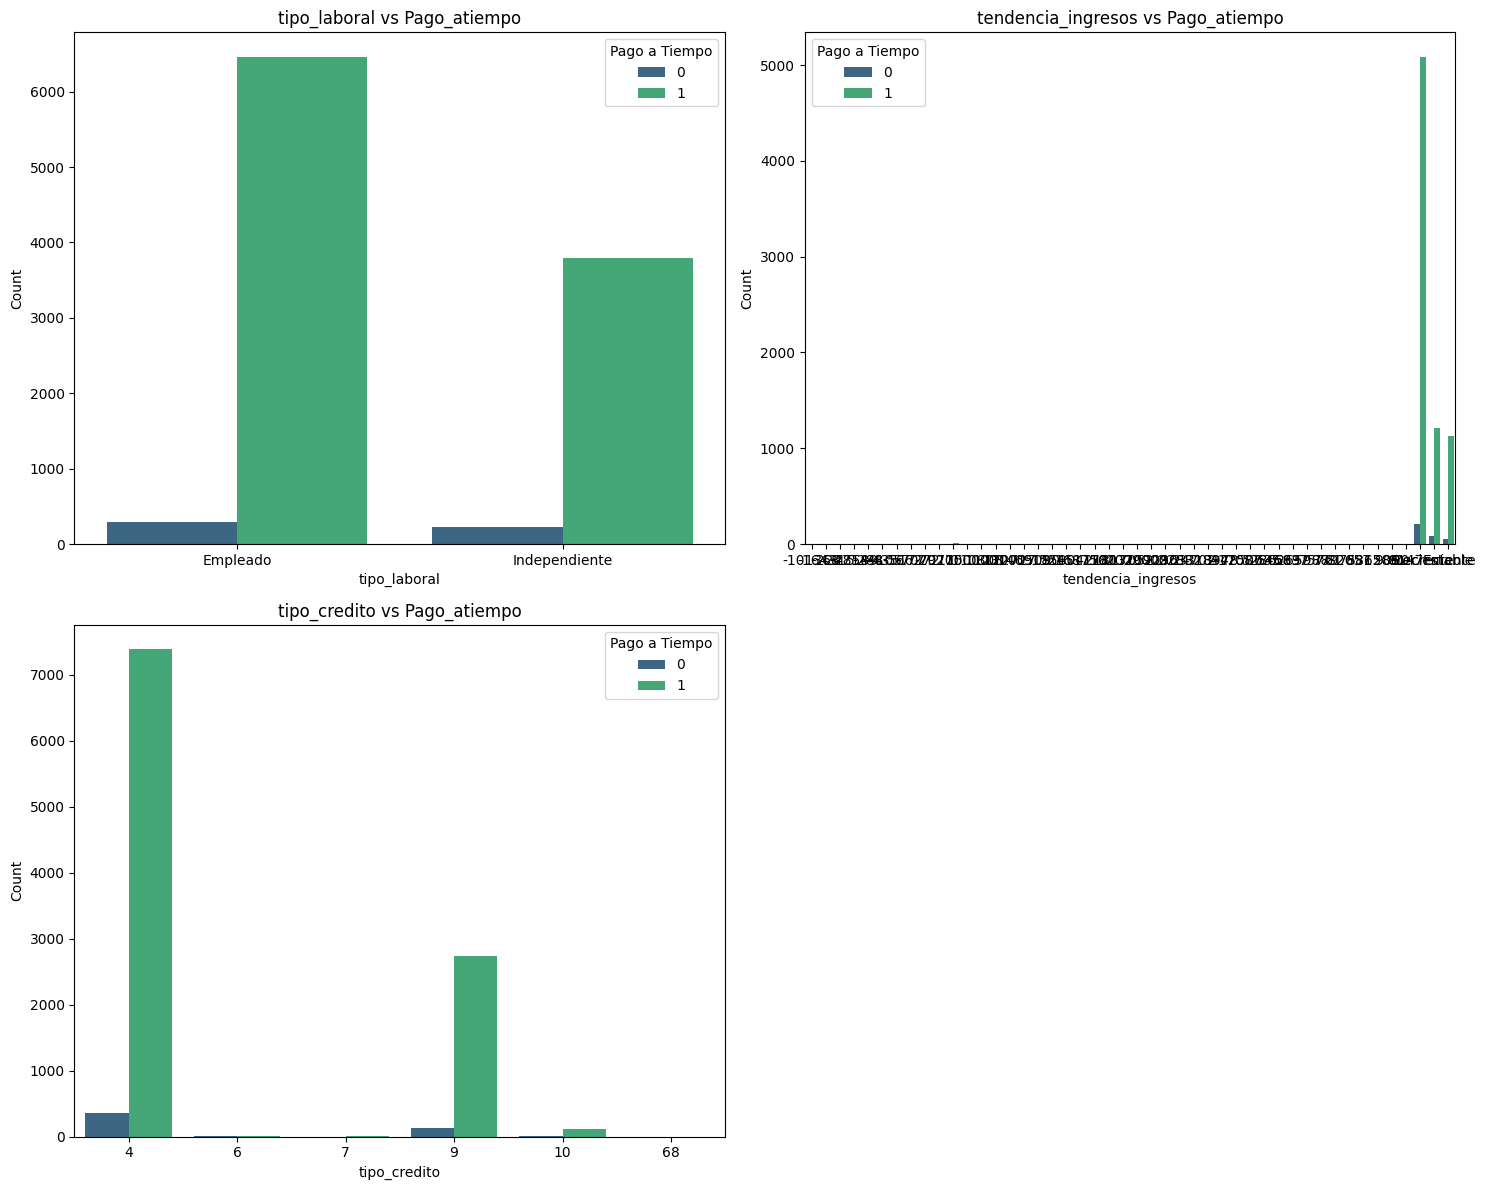

In [12]:
target_variable = 'Pago_atiempo'

# Bivariate Analysis: Numerical Features vs. Target Variable
# Solo las 5 mas "importantes"
# (se descarta la variable puntaje a falta de confirmacion de su data leakage)
numerical_features = ['huella_consulta', 'saldo_mora', 'puntaje_datacredito','plazo_meses','capital_prestado']

plt.figure(figsize=(15, 18))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 2, i + 1) # Ajustado a 3x2 para soportar 5 o 6 gráficos
    sns.boxplot(x=target_variable, y=col, data=data)
    plt.title(f'{col} vs {target_variable}')
    plt.xlabel('Pago a Tiempo (0=No, 1=Sí)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Bivariate Analysis: Categorical Features vs. Target Variable
categorical_features = ['tipo_laboral', 'tendencia_ingresos', 'tipo_credito']

plt.figure(figsize=(15, 12))
for i, col in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.countplot(x=col, hue=target_variable, data=data, palette='viridis')
    plt.title(f'{col} vs {target_variable}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend(title='Pago a Tiempo')
plt.tight_layout()
plt.show()



* Puntaje Datacredito: Es el predictor visual más claro; los clientes con
cumplimiento de pago muestran puntajes más altos y concentrados, mientras que los casos de mora presentan una dispersión mayor hacia valores bajos.
* Outliers en Montos y Mora: Tanto `capital_prestado` como `saldo_mora` muestran valores extremos significativos. La mayoría de los incumplimientos ocurren en créditos de montos bajos, pero con saldos en mora muy dispersos.
* Huella y Plazo: No se observa una separación drástica en las medianas de `huella_consulta` o `plazo_meses` entre ambos grupos, lo que sugiere que su impacto lineal es limitado.
* Desbalance de Clases: Los countplots confirman visualmente que el grupo de `Pago a tiempo` domina todas las categorías, lo que obligará a usar técnicas de balanceo o métricas específicas (como F1-Score) en el modelado.
* Concentración en Productos: La mora se distribuye proporcionalmente a la frecuencia de los productos, siendo el `tipo_credito` 4 el que más registros aporta en ambos estados.

**ANALISIS MULTIVARIABLE**

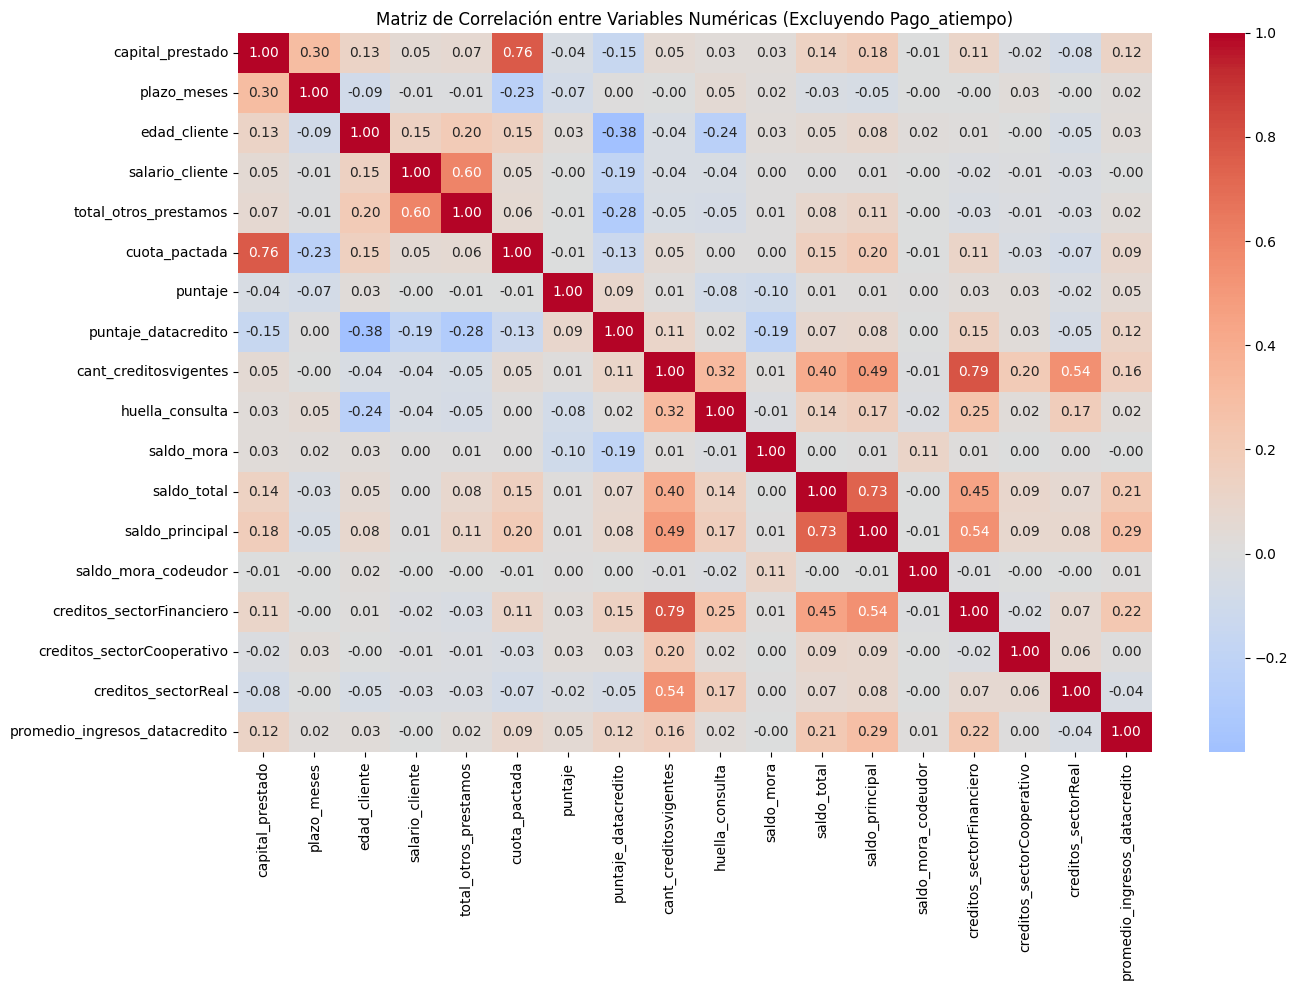


Correlaciones más fuertes (excluyendo Pago_atiempo):
creditos_sectorFinanciero      cant_creditosvigentes            0.791253
cant_creditosvigentes          creditos_sectorFinanciero        0.791253
capital_prestado               cuota_pactada                    0.764104
cuota_pactada                  capital_prestado                 0.764104
saldo_principal                saldo_total                      0.734664
saldo_total                    saldo_principal                  0.734664
total_otros_prestamos          salario_cliente                  0.596990
salario_cliente                total_otros_prestamos            0.596990
creditos_sectorReal            cant_creditosvigentes            0.540677
cant_creditosvigentes          creditos_sectorReal              0.540677
creditos_sectorFinanciero      saldo_principal                  0.537307
saldo_principal                creditos_sectorFinanciero        0.537307
cant_creditosvigentes          saldo_principal                  0.4859

In [13]:
data_numeric_only = data.select_dtypes(include=np.number)

# 'Pago_atiempo' (the target variable) is a categorical variable and was already excluded
# when 'data_numeric_only' was created. Therefore, no explicit drop operation is needed for it here.
data_numeric_no_sale_price = data_numeric_only

# Calcular la matriz de correlación para las variables numéricas restantes
correlation_matrix_no_sale_price = data_numeric_no_sale_price.corr()

# Crear un mapa de calor de correlaciones
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix_no_sale_price, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación entre Variables Numéricas (Excluyendo Pago_atiempo)')
plt.tight_layout()
plt.show()

# Opcional: Mostrar las correlaciones más fuertes (absolutas) para identificar multicolinealidad
correlations_no_sale_price = correlation_matrix_no_sale_price.unstack()
sorted_correlations_no_sale_price = correlations_no_sale_price.sort_values(key=abs, ascending=False)

# Eliminar autocorrelaciones y duplicados
high_correlations_no_sale_price = sorted_correlations_no_sale_price[sorted_correlations_no_sale_price != 1.0]
high_correlations_no_sale_price = high_correlations_no_sale_price[~high_correlations_no_sale_price.index.duplicated()]
print("\nCorrelaciones más fuertes (excluyendo Pago_atiempo):")
print(high_correlations_no_sale_price.head(30))

La matriz muestra relaciones lineales moderadas y fuertes entre varios predictores, destacando `creditos_sectorFinanciero–cant_creditosvigentes` (r=0.79), `capital_prestado–cuota_pactada` (r=0.76) y `saldo_principal–saldo_total` (r=0.73). Esto sugiere posible redundancia o multicolinealidad entre algunas variables, que deberá considerarse en una futura etapa de modelado. También se observan relaciones relevantes entre `edad_cliente y puntaje_datacredito` (r=-0.38) y entre `total_otros_prestamos y salario_cliente` (r=0.60). Estas correlaciones describen relaciones entre los predictores, pero no constituyen por sí mismas un criterio para eliminar variables.

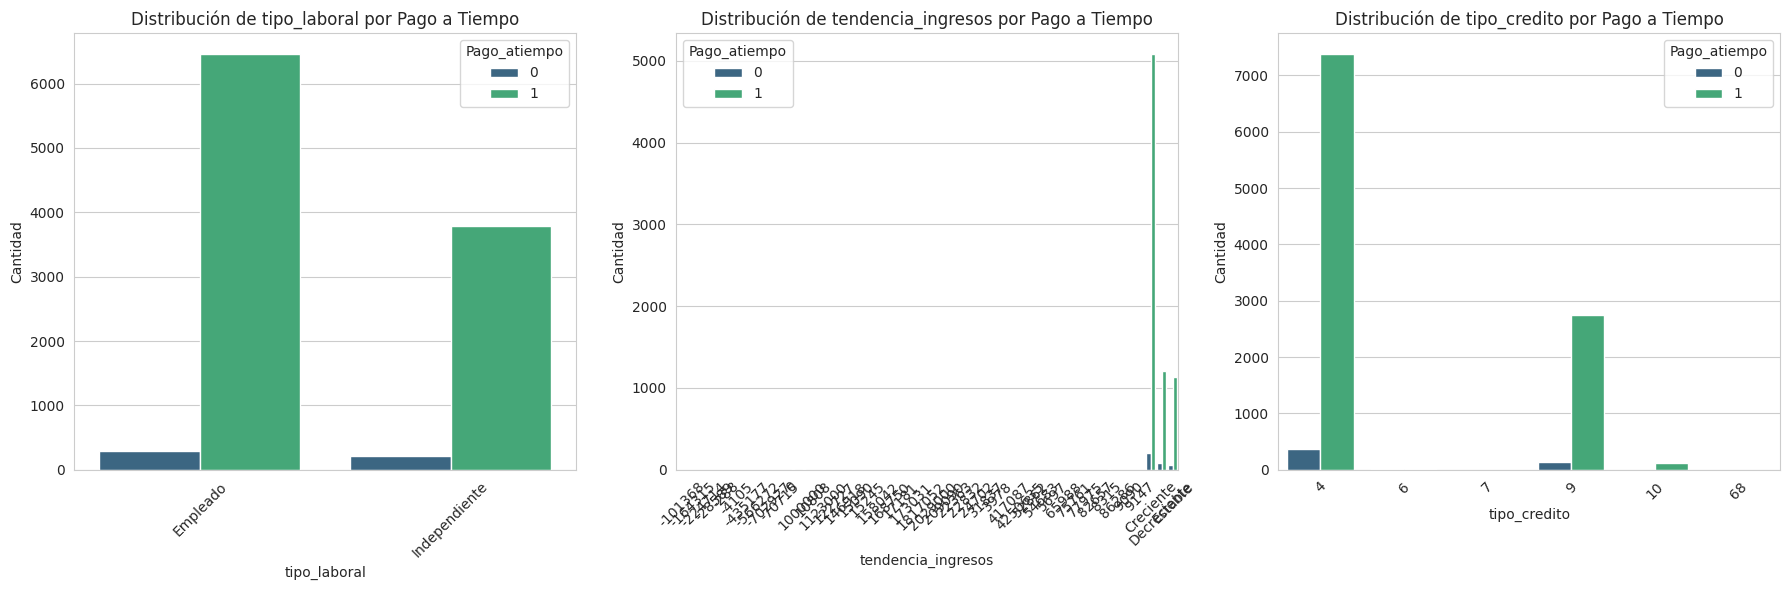

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
categorical_vars = ['tipo_laboral', 'tendencia_ingresos', 'tipo_credito']

plt.figure(figsize=(18, 6))
for i, var in enumerate(categorical_vars):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=var, hue='Pago_atiempo', data=data, palette='viridis')
    plt.title(f'Distribución de {var} por Pago a Tiempo')
    plt.xlabel(var)
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **4. Analisis**

**REGLAS DE VALIDACION DE LOS DATOS**


1. `edad_cliente`: rango válido de negocio ≈ [18, 90]. Valores 121–123 son sentinela de dato faltante, no edad real.
2. `puntaje_datacredito`: valores 0 y negativos (-7) son inconsistentes con un score real de central de riesgo; deben tratarse como nulo disfrazado, vinculado al mismo fallo de fuente externa que afecta a promedio_ingresos_datacredito y tendencia_ingresos.
3. `tipo_credito`: dominio válido = {4, 6, 7, 9, 10}. El valor 68 no pertenece al dominio esperado.
4. `tendencia_ingresos`: dominio válido = {Creciente, Decreciente, Estable}. Los 47 valores numéricos deben marcarse como nulo, no dejarse como categorías nuevas.
5. `salario_cliente`: definir un techo de ingreso mensual creíble (a validar con negocio, ej. algún múltiplo del salario típico observado ~$3M); valores en miles de millones sugieren error de escala/captura, no ingresos reales.
6. `total_otros_prestamos`: mismo tipo de regla de tope razonable que salario_cliente.
7. `puntaje`: rango de negocio esperado a confirmar (posiblemente 0-950); valores negativos no encajan. Por su correlación casi perfecta con el target, se recomienda excluirla de cualquier modelo predictivo salvo que se confirme que no hay fuga de información temporal.
8. `promedio_ingresos_datacredito`, `tendencia_ingresos`, `puntaje_datacredito`: sus nulos están relacionados con un fallo común de una fuente externa (consulta a central de riesgo), cualquier imputación futura debería tratarlas de forma conjunta, no independiente.
9. `saldo_mora_codeudor`: 99.97% de los valores no-nulos son cero, candidata a transformarse en variable indicador binario en feature engineering, en vez de mantenerse como monto continuo.
10. `fecha_prestamo`: cualquier modelo debe considerar el efecto de maduración (vintage), créditos recientes no han tenido tiempo de caer en mora, lo que puede sesgar el target si no se controla por antigüedad.
11. `Pago_atiempo`: el desbalance de clases (95.25%/4.75%) debe condicionar la métrica de evaluación del futuro modelo (no usar accuracy simple; considerar recall/F1/AUC o técnicas de balanceo).








**IDENTIFICACION DE ATRIBUTO OBJETIVO (Target)**

En este proyecto de clasificación supervisada, el objetivo es predecir la probabilidad de incumplimiento de un crédito.

*   Clasificacion Binaria (`Pago_atiempo`): Aquí el objetivo es predecir si el usuario cumplirá con el pago de su crédito en los tiempos establecidos.
     
* Regresión (Predicción de Montos): En lugar de predecir si paga, podrías predecir cuánto dejará de pagar usando saldo_mora como target. Esto ayuda a priorizar la cobranza por monto recuperable.

* Clasificación Multiclase (Severidad): Podrías segmentar el target en niveles: 'Al día', 'Mora temprana' (1-30 días) y 'Mora tardía' (>90 días). Esto requiere cruzar los saldos con la fecha de pago real.

* Predicción de Capacidad (Aprobación): Si el objetivo fuera comercial, el target podría ser el `capital_prestado` para predecir cuánto crédito otorgar a nuevos clientes similares.

**TRANSFORMACIONES A TENER EN CUENTA PARA EL MODELADO**

Para avanzar hacia la etapa de limpieza y modelado, se deben aplicar las siguientes transformaciones:

*   Tratamiento de Escala y Outliers: Aplicar `StandardScaler` o `MinMaxScaler` a las variables de ingresos y montos (`salario_cliente`, `total_otros_prestamos`) para mitigar el impacto de los errores de digitación (millones vs. miles de millones).
*   Manejo de Multicolinealidad: Evaluar el Factor de Inflación de la Varianza (VIF) y considerar la eliminación de una de las variables en los pares altamente correlacionados (ej. mantener solo `saldo_total` y descartar `saldo_principal`).
*   Ingeniería de Características (Binning/Dummies):
    *   Convertir `saldo_mora_codeudor` en una variable binaria (tiene mora: Sí/No) debido a su alta concentración en cero.
    *   Agrupar categorías minoritarias en `tipo_credito` (ej. el valor atípico '68').
*   Imputación por Fallo de Fuente: Dado que los nulos en `promedio_ingresos_datacredito`, `tendencia_ingresos` y `puntaje_datacredito` son concurrentes, se debe usar una técnica de imputación que considere esta relación, o crear una bandera de "Fallo en Consulta Centrales".
*   Balanceo del Target: Implementar técnicas como SMOTE, submuestreo o ajuste de pesos de clase en el modelo para compensar el fuerte desbalance (95% vs 5%).

### **PROPUESTA DE INGENIERIA DE CARACTERISTICAS (Features Derivadas)**

Para mejorar la capacidad predictiva del modelo, se pueden realizar las siguientes variables calculadas:

1.  Derivadas de Tiempo (`fecha_prestamo`):
    *   `antiguedad_credito_dias`: Días transcurridos desde el desembolso hasta la fecha de corte del análisis. Crucial para identificar el efecto vintage (créditos muy jóvenes rara vez están en mora).
    *   `mes_desembolso` / `trimestre`: Para capturar estacionalidad (ej. gastos de fin de año o inicio de clases).

2.  Ratios Financieros (Capacidad de Pago):
    *   `ratio_cuota_ingreso`: `cuota_pactada` / `salario_cliente`. Indica qué porcentaje del ingreso compromete el cliente en este crédito.
    *   `endeudamiento_total`: (`cuota_pactada` + `total_otros_prestamos`) / `salario_cliente` (siempre que se normalicen las escalas de salario).

3.  Comportamiento Externo:
    *   `intensidad_busqueda`: `huella_consulta` / `cant_creditosvigentes`. Un ratio alto puede indicar desesperación por liquidez.
    *   `tiene_mora_externa`: Variable binaria basada en si `saldo_mora` > 0 o `saldo_mora_codeudor` > 0.